# Driving School Installs Prediction (ARIMA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from utils import check_stationarity

warnings.filterwarnings("ignore")

## Hyperparameters & Config

In [2]:
DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
TARGET_COL = "Daily User Installs"
TRAIN_RATIO = 0.8

## Loading Data

In [3]:
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

# Ensure data is univariate for basic ARIMA
series = df[TARGET_COL]
series.head()

Date
2019-09-02    2
2019-09-03    1
2019-09-04    2
2019-09-05    3
2019-09-06    6
Name: Daily User Installs, dtype: int64

## Stationarity Check

In [4]:
check_stationarity(series, title=TARGET_COL)

--- Stationarity Tests for Daily User Installs ---
ADF Statistic: -3.9122
ADF p-value: 0.0019
ADF Critical Values:
   1%: -3.4332
   5%: -2.8628
   10%: -2.5674
KPSS Statistic: 0.5268
KPSS p-value: 0.0356
KPSS Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: The series is likely non-stationary.


## Train/Test Split

In [5]:
train_size = int(len(series) * TRAIN_RATIO)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 1850
Test size: 463


## Auto-ARIMA to Find Optimal Parameters (p, d, q)

In [6]:
model_auto = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=41581.263, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=41583.202, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=41583.197, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=41579.264, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=41575.965, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=41570.133, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=41578.572, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=41570.032, Time=0.15 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=41578.002, Time=0.09 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=41472.810, Time=0.31 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=41544.449, Time=0.07 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=41474.466, Time=0.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.00 sec
 ARIMA(3,1,2)(0,0,0)[0] interce

## Fit Final ARIMA Model

In [7]:
p, d, q = model_auto.order
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Daily User Installs   No. Observations:                 1850
Model:                  ARIMA(4, 1, 1)   Log Likelihood              -20729.405
Date:                 Mon, 30 Mar 2026   AIC                          41470.811
Time:                         16:37:22   BIC                          41503.945
Sample:                     09-02-2019   HQIC                         41483.025
                          - 09-24-2024                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8305      0.010    -82.689      0.000      -0.850      -0.811
ar.L2         -0.0746      0.010     -7.631      0.000      -0.094      -0.055
ar.L3         -0.0875      0.012     -7.062 

## Forecasting & Evaluation

------------------------------
ARIMA EVALUATION RESULTS
------------------------------
RMSE: 24187.29 installs
MAE:  18817.52 installs
------------------------------


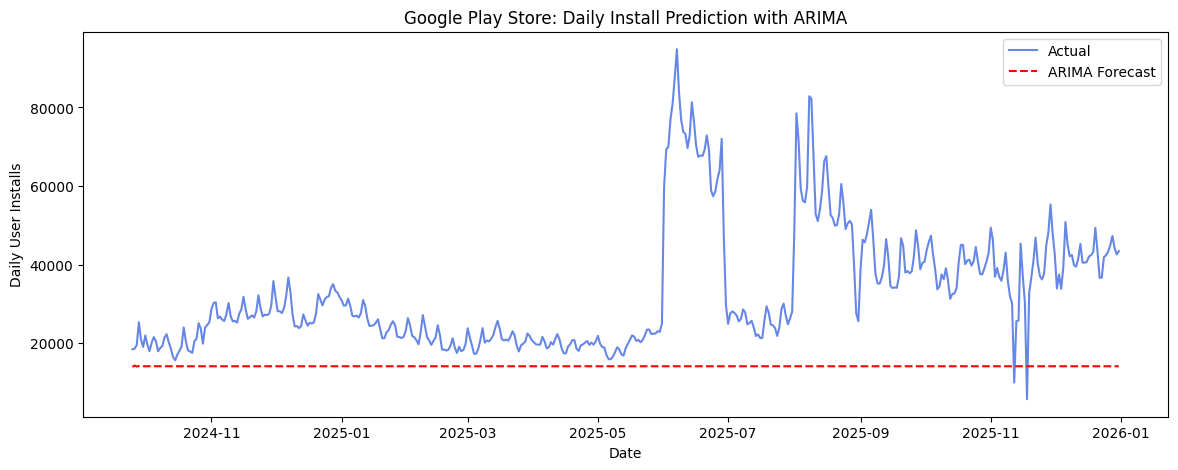

In [8]:
forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("-" * 30)
print("ARIMA EVALUATION RESULTS")
print("-" * 30)
print(f"RMSE: {rmse:.2f} installs")
print(f"MAE:  {mae:.2f} installs")
print("-" * 30)

plt.figure(figsize=(14, 5))
# plt.plot(train.index, train, label="Train", color="gray", alpha=0.5)
plt.plot(test.index, test, label="Actual", color="royalblue", alpha=0.8)
plt.plot(test.index, forecast, label="ARIMA Forecast", color="red", linestyle="--")
plt.title("Google Play Store: Daily Install Prediction with ARIMA")
plt.xlabel("Date")
plt.ylabel("Daily User Installs")
plt.legend()
plt.show()

## Residual Analysis

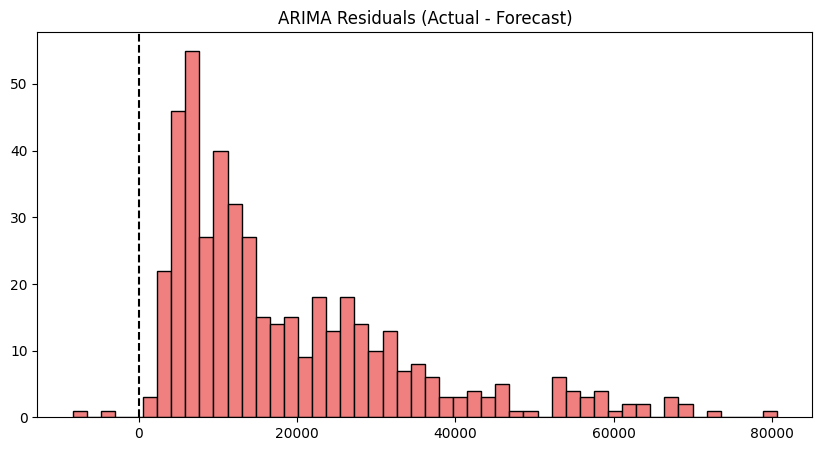

In [9]:
residuals = test - forecast
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color="lightcoral", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.title("ARIMA Residuals (Actual - Forecast)")
plt.show()